<a href="https://colab.research.google.com/github/pavanadithyak/Survey-Data-Health-Checker/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fpdf2 scipy scikit-learn pandas numpy matplotlib seaborn -q

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from fpdf import FPDF
import warnings
warnings.filterwarnings('ignore')
data = fetch_openml('adult', version=2, as_frame=True)
df = data.frame
df.replace('?', np.nan, inplace=True)
print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:

print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class', 'time_chunk']



── SEX ──
  Male                         sample=66.8%  census=49.0%  delta=17.8%  🚨 UNDERREPRESENTED
  Female                       sample=33.2%  census=51.0%  delta=17.8%  🚨 UNDERREPRESENTED

── RACE ──
  White                        sample=85.5%  census=60.0%  delta=25.5%  🚨 UNDERREPRESENTED
  Black                        sample=9.6%  census=13.0%  delta=3.4%  ✅ OK
  Asian-Pac-Islander           sample=3.1%  census=6.0%  delta=2.9%  ✅ OK
  Amer-Indian-Eskimo           sample=1.0%  census=1.0%  delta=0.0%  ✅ OK
  Other                        sample=0.8%  census=20.0%  delta=19.2%  🚨 UNDERREPRESENTED


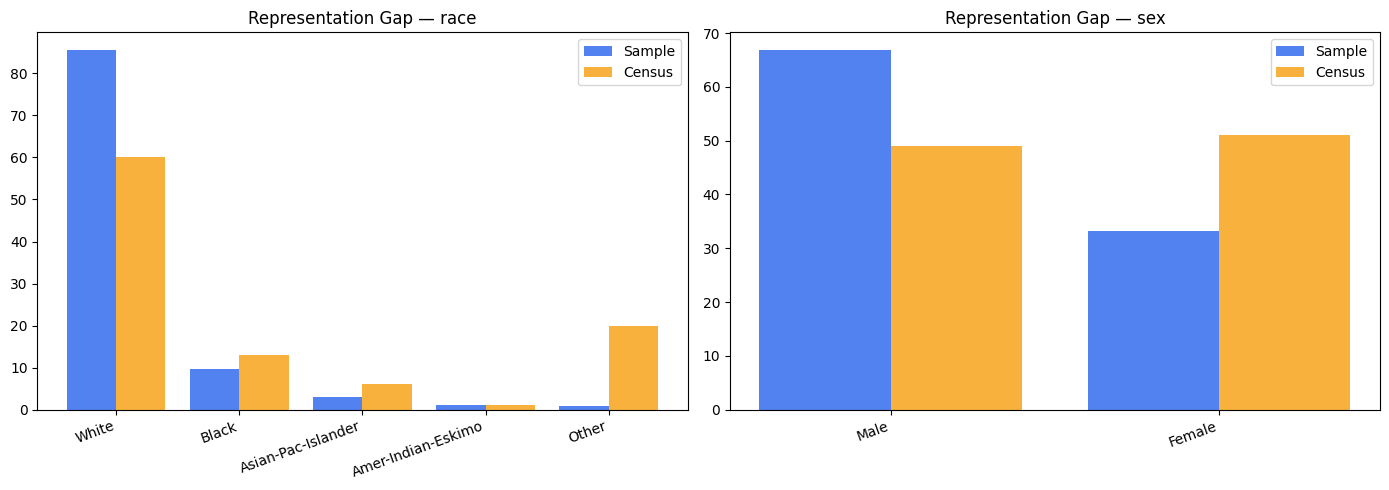


Flags found: 4


In [ ]:
CENSUS = {
    'sex': {'Male': 0.49, 'Female': 0.51},
    'race': {'White': 0.60, 'Black': 0.13, 'Asian-Pac-Islander': 0.06,
             'Amer-Indian-Eskimo': 0.01, 'Other': 0.20}
}

rep_flags = []

for col, benchmarks in CENSUS.items():
    sample_dist = df[col].value_counts(normalize=True)
    print(f"\n── {col.upper()} ──")
    for group, census_pct in benchmarks.items():
        sample_pct = sample_dist.get(group, 0)
        delta = abs(sample_pct - census_pct)
        flag = "🚨 UNDERREPRESENTED" if delta > 0.05 else "✅ OK"
        rep_flags.append({'column': col, 'group': group,
                          'sample_%': round(sample_pct*100,1),
                          'census_%': round(census_pct*100,1),
                          'delta': round(delta*100,1),
                          'flag': flag})
        print(f"  {group:<28} sample={sample_pct:.1%}  census={census_pct:.1%}  delta={delta:.1%}  {flag}")

rep_df = pd.DataFrame(rep_flags)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, grp) in zip(axes, rep_df.groupby('column')):
    x = range(len(grp))
    ax.bar(x, grp['sample_%'], width=0.4, label='Sample', color='#2563EB', alpha=0.8)
    ax.bar([i+0.4 for i in x], grp['census_%'], width=0.4, label='Census', color='#F59E0B', alpha=0.8)
    ax.set_xticks([i+0.2 for i in x])
    ax.set_xticklabels(grp['group'], rotation=20, ha='right')
    ax.set_title(f'Representation Gap — {col}')
    ax.legend()
plt.tight_layout()
plt.savefig('rep_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFlags found:", rep_df[rep_df['flag'].str.contains('🚨')].shape[0])

── KS DRIFT TEST ──
  education-num          KS=0.141  p=0.0000  🚨 DRIFT DETECTED
  hours-per-week         KS=0.377  p=0.0000  🚨 DRIFT DETECTED
  capital-gain           KS=0.103  p=0.0000  🚨 DRIFT DETECTED
  fnlwgt                 KS=0.120  p=0.0000  🚨 DRIFT DETECTED


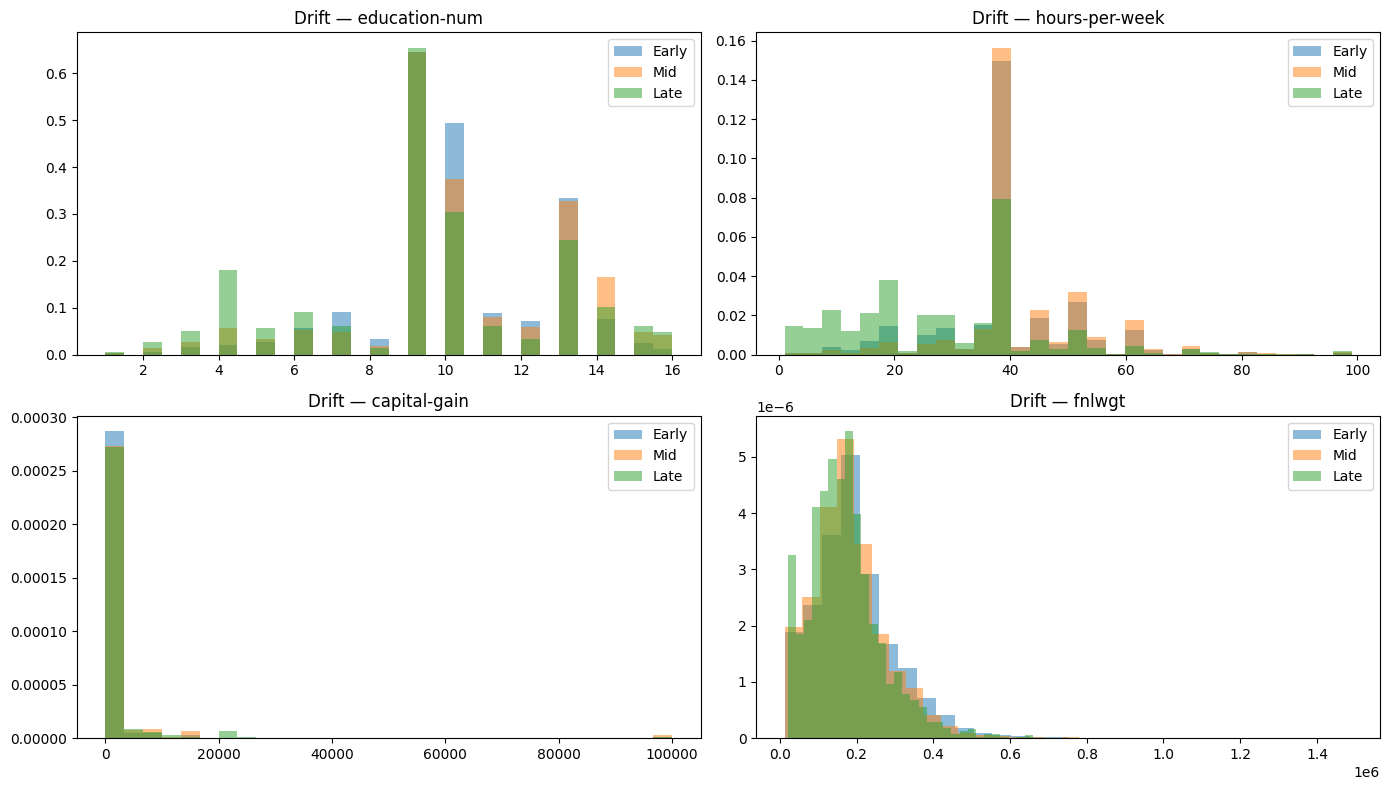

In [ ]:
df['time_chunk'] = pd.cut(df['age'].astype(float),
                           bins=3, labels=['Early', 'Mid', 'Late'])

numeric_cols = ['education-num', 'hours-per-week', 'capital-gain', 'fnlwgt']
drift_flags = []

print("── KS DRIFT TEST ──")
for col in numeric_cols:
    groups = [g[col].dropna().astype(float)
              for _, g in df.groupby('time_chunk')]

    ks_stat, p_val = stats.ks_2samp(groups[0], groups[2])
    flag = "🚨 DRIFT DETECTED" if p_val < 0.05 else "✅ STABLE"
    drift_flags.append({'feature': col, 'ks_stat': round(ks_stat,3),
                        'p_value': round(p_val,4), 'flag': flag})
    print(f"  {col:<22} KS={ks_stat:.3f}  p={p_val:.4f}  {flag}")

drift_df = pd.DataFrame(drift_flags)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    for label, grp in df.groupby('time_chunk'):
        vals = grp[col].dropna().astype(float)
        ax.hist(vals, bins=30, alpha=0.5, label=label, density=True)
    ax.set_title(f'Drift — {col}')
    ax.legend()
plt.tight_layout()
plt.savefig('drift.png', dpi=150, bbox_inches='tight')
plt.show()

── CLASS BALANCE ──
class
<=50K    37155
>50K     11687
Name: count, dtype: int64

Ratio: 0.31  🚨 IMBALANCED


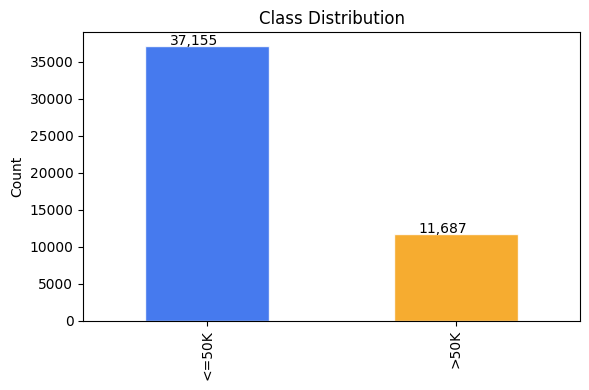


══════════════════════════════
  SURVEY HEALTH SCORE: 25.0%  [D]
  Total checks : 12
  Flags raised : 9
══════════════════════════════


In [ ]:
# Class balance
target = 'class'
counts = df[target].value_counts()
balance_ratio = counts.min() / counts.max()
balance_flag = "🚨 IMBALANCED" if balance_ratio < 0.4 else "✅ BALANCED"

print("── CLASS BALANCE ──")
print(counts)
print(f"\nRatio: {balance_ratio:.2f}  {balance_flag}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#2563EB','#F59E0B'], alpha=0.85, edgecolor='white')
ax.set_title('Class Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+0.1, p.get_height()+100))
plt.tight_layout()
plt.savefig('balance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── OVERALL HEALTH SCORE ──
total_checks = len(rep_df) + len(drift_df) + 1
total_flags  = (rep_df['flag'].str.contains('🚨').sum() +
                drift_df['flag'].str.contains('🚨').sum() +
                (1 if '🚨' in balance_flag else 0))

score = round((1 - total_flags/total_checks) * 100, 1)
grade = "A" if score>=90 else "B" if score>=75 else "C" if score>=60 else "D"

print(f"\n══════════════════════════════")
print(f"  SURVEY HEALTH SCORE: {score}%  [{grade}]")
print(f"  Total checks : {total_checks}")
print(f"  Flags raised : {total_flags}")
print(f"══════════════════════════════")

In [ ]:
class SurveyReport(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 15)
        self.set_fill_color(27, 58, 107)
        self.set_text_color(255, 255, 255)
        self.cell(0, 12, 'Survey Data Health Report', fill=True, ln=True, align='C')
        self.ln(4)

    def section(self, title):
        self.set_font('Helvetica', 'B', 11)
        self.set_text_color(37, 99, 235)
        self.cell(0, 8, title, ln=True)
        self.set_draw_color(37, 99, 235)
        self.line(10, self.get_y(), 200, self.get_y())
        self.ln(3)
        self.set_text_color(30, 41, 59)

    def row(self, cols, widths, bold=False):
        self.set_font('Helvetica', 'B' if bold else '', 9)
        for col, w in zip(cols, widths):
            self.cell(w, 7, str(col), border=1)
        self.ln()

pdf = SurveyReport()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)

pdf.set_font('Helvetica', 'B', 13)
pdf.set_fill_color(239, 246, 255)
pdf.set_text_color(27, 58, 107)
pdf.cell(0, 12, f'Overall Health Score: {score}%  [Grade {grade}]  |  Flags: {total_flags}/{total_checks}',
         fill=True, ln=True, align='C')
pdf.ln(4)

pdf.section('1. Representation Gaps vs Census Benchmarks')
pdf.row(['Demographic','Group','Sample %','Census %','Delta %','Status'],
        [30,40,25,25,25,45], bold=True)
for _, r in rep_df.iterrows():
    status = 'UNDERREPRESENTED' if '🚨' in r['flag'] else 'OK'
    pdf.row([r['column'], r['group'], r['sample_%'], r['census_%'], r['delta'], status],
            [30,40,25,25,25,45])
pdf.image('rep_gap.png', w=180)
pdf.ln(4)

pdf.section('2. Respondent Drift (KS Test - Early vs Late Cohort)')
pdf.row(['Feature','KS Stat','p-value','Status'], [55,35,35,65], bold=True)
for _, r in drift_df.iterrows():
    status = 'DRIFT DETECTED' if '🚨' in r['flag'] else 'STABLE'
    pdf.row([r['feature'], r['ks_stat'], r['p_value'], status], [55,35,35,65])
pdf.image('drift.png', w=180)
pdf.ln(4)

pdf.section('3. Class Imbalance Check')
pdf.set_font('Helvetica', '', 10)
status = 'IMBALANCED' if '🚨' in balance_flag else 'BALANCED'
pdf.cell(0, 7, f'Balance ratio: {balance_ratio:.2f}  |  Status: {status}', ln=True)
pdf.image('balance.png', w=100)

pdf.output('survey_health_report.pdf')
print("✅ Report saved: survey_health_report.pdf")

from google.colab import files
files.download('survey_health_report.pdf')

✅ Report saved: survey_health_report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>